# Eagles Stops visualization (Square Regions)

## Read in data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gameday_comparison = pd.read_csv("../data/all_days_aggregated_stops.csv", index_col=0)
gameday_comparison

/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_22230/2575892783.py:1: DtypeWarning: Columns (5,6,7,8,10) have mixed types. Specify dtype option on import or set low_memory=False.
  gameday_comparison = pd.read_csv("all_days_aggregated_stops.csv", index_col=0)


,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday
0,2014-01-01,0,4434_-6395,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2014-01-01,0,4434_-6394,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2014-01-01,0,4438_-6399,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2014-01-01,0,4435_-6398,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2014-01-01,0,4436_-6399,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15099115,2018-04-14,23,4427_-6392,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
15099116,2018-04-14,23,4450_-6397,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
15099117,2018-04-14,23,4449_-6396,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
15099118,2018-04-14,23,4446_-6401,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Remove Extra Columns

In [3]:
gameday_comparison.drop(columns=['Opp', 'TeamScore', 'OppScore', 'DefTO', 'OffTO', 'Wins', 'Losses','Giants', 'Cowboys'], inplace=True)
gameday_comparison.columns

Index(['date', 'hour', 'region', 'stop_count', 'Game', 'Day', 'StartTime',
       'xEndTime', 'Home', 'PointDiff', 'TODiff', 'Win', 'OT', 'Season',
       'Streak', 'Rivalry', 'RegularSeason', 'Division', 'ConfChamp',
       'SuperBowl', 'gameday'],
      dtype='object')

In [4]:
gameday_comparison

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,PointDiff,...,Win,OT,Season,Streak,Rivalry,RegularSeason,Division,ConfChamp,SuperBowl,gameday
0,2014-01-01,0,4434_-6395,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2014-01-01,0,4434_-6394,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2014-01-01,0,4438_-6399,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2014-01-01,0,4435_-6398,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2014-01-01,0,4436_-6399,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15099115,2018-04-14,23,4427_-6392,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
15099116,2018-04-14,23,4450_-6397,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
15099117,2018-04-14,23,4449_-6396,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
15099118,2018-04-14,23,4446_-6401,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Gamedays v Nongamedays

In [5]:
gameday_comparison = gameday_comparison[['date', 'hour', 'region', 'stop_count', 'gameday']]
gameday_comparison

,date,hour,region,stop_count,gameday
0,2014-01-01,0,4434_-6395,0,0
1,2014-01-01,0,4434_-6394,0,0
2,2014-01-01,0,4438_-6399,0,0
3,2014-01-01,0,4435_-6398,0,0
4,2014-01-01,0,4436_-6399,0,0
...,...,...,...,...,...
15099115,2018-04-14,23,4427_-6392,0,0
15099116,2018-04-14,23,4450_-6397,0,0
15099117,2018-04-14,23,4449_-6396,0,0
15099118,2018-04-14,23,4446_-6401,0,0


### Map comparison

#### Re-extract km bins from region

In [6]:
gameday_comparison[['lat_bin', 'lng_bin']] = gameday_comparison['region'].str.split('_', expand=True).astype(int)

/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_22230/2131964990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gameday_comparison[['lat_bin', 'lng_bin']] = gameday_comparison['region'].str.split('_', expand=True).astype(int)
/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_22230/2131964990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gameday_comparison[['lat_bin', 'lng_bin']] = gameday_comparison['region'].str.split('_', expand=True).astype(int)


#### Compute average stops per region

In [7]:
# Game days
game_avg = (
    gameday_comparison[gameday_comparison['gameday'] == 1]
    .groupby(['lat_bin', 'lng_bin'])['stop_count']
    .mean()
    .reset_index()
)

# Non-game days
nongame_avg = (
    gameday_comparison[gameday_comparison['gameday'] == 0]
    .groupby(['lat_bin', 'lng_bin'])['stop_count']
    .mean()
    .reset_index()
)


#### normalize values for coloring

In [8]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

game_avg['norm'] = normalize(game_avg['stop_count'])
nongame_avg['norm'] = normalize(nongame_avg['stop_count'])


#### Create plotting function

In [9]:
km_to_deg_lat = 1 / 111
km_to_deg_lng = 0.011758845009850643

In [10]:
center_lat = gameday_comparison['lat_bin'].mean() * km_to_deg_lat
center_lng = gameday_comparison['lng_bin'].mean() * km_to_deg_lng

In [11]:
import folium
import matplotlib
import matplotlib.colors as colors
import branca.colormap as bcm

def create_map(data, title):

    m = folium.Map(location=[center_lat, center_lng], zoom_start=11)

    # Colormap
    colormap = matplotlib.colormaps['YlOrRd']

    # Create legend scale using branca
    min_val = data['stop_count'].min()
    max_val = data['stop_count'].max()

    legend = bcm.LinearColormap(
        colors=[colormap(i) for i in range(0, 256)],
        vmin=min_val,
        vmax=max_val,
    )

    legend.caption = f"{title}: Avg Stops per Hour"
    legend.add_to(m)

    # Draw grid
    for _, row in data.iterrows():
        lat_min = row['lat_bin'] * km_to_deg_lat
        lng_min = row['lng_bin'] * km_to_deg_lng

        lat_max = lat_min + km_to_deg_lat
        lng_max = lng_min + km_to_deg_lng

        norm_val = (row['stop_count'] - min_val) / (max_val - min_val)
        color = colors.rgb2hex(colormap(norm_val))

        folium.Rectangle(
            bounds=[[lat_min, lng_min], [lat_max, lng_max]],
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            tooltip=f"Avg Stops: {row['stop_count']:.2f}"
        ).add_to(m)

    # Add Eagles Stadium marker
    folium.CircleMarker(
    location=[39.9014, -75.1676],
    radius=12,
    color='green',
    fill=True,
    fill_opacity=1,
    tooltip="Eagles Stadium"
    ).add_to(m)


    return m


#### Create Maps

In [12]:
game_map = create_map(game_avg, "Game Map")
nongame_map = create_map(nongame_avg, "Non-Game Map")

In [13]:
game_map

In [14]:
nongame_map

### Histogram Comparison

In [15]:
daily_stops = (
    gameday_comparison
    .groupby(['date', 'gameday'])['stop_count']
    .sum()
    .reset_index()
)
daily_stops

,date,gameday,stop_count
0,2014-01-01,0,44
1,2014-01-02,0,114
2,2014-01-03,0,25
3,2014-01-04,0,28
4,2014-01-05,0,51
...,...,...,...
1560,2018-04-10,0,1149
1561,2018-04-11,0,1311
1562,2018-04-12,0,1087
1563,2018-04-13,0,1153


/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_22230/3581501998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gameday_label', y='stop_count', data=daily_stops, palette='Set2')


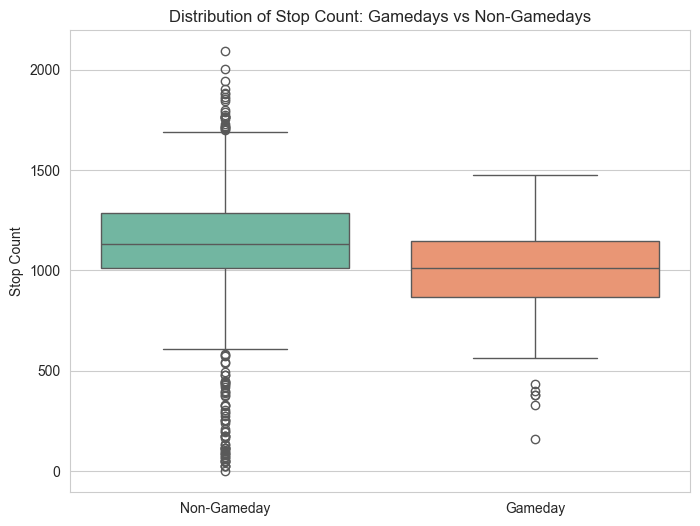

In [16]:
# Convert gameday to a string label for nicer x-axis
daily_stops['gameday_label'] = daily_stops['gameday'].map({0: 'Non-Gameday', 1: 'Gameday'})

# Create boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='gameday_label', y='stop_count', data=daily_stops, palette='Set2')
plt.title('Distribution of Stop Count: Gamedays vs Non-Gamedays')
plt.ylabel('Stop Count')
plt.xlabel('')
plt.show()

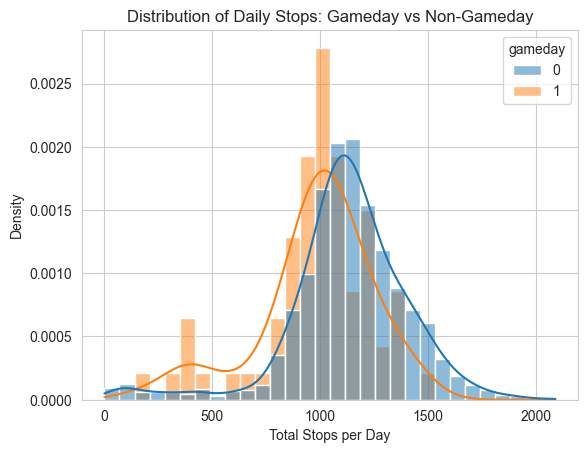

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=daily_stops,
    x='stop_count',
    hue='gameday',
    bins=30,
    kde=True,
    stat='density',
    common_norm=False
)

plt.title('Distribution of Daily Stops: Gameday vs Non-Gameday')
plt.xlabel('Total Stops per Day')
plt.ylabel('Density')
plt.show()


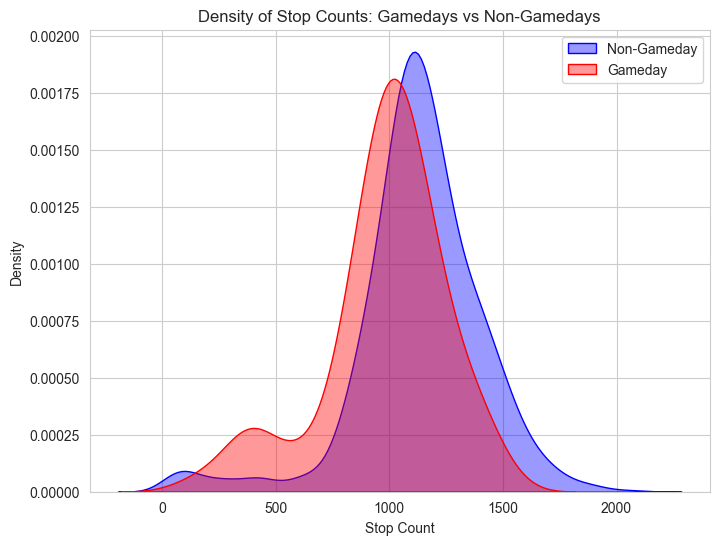

In [18]:
# Separate the data
gameday_counts = daily_stops[daily_stops['gameday'] == 1]['stop_count']
non_gameday_counts = daily_stops[daily_stops['gameday'] == 0]['stop_count']

plt.figure(figsize=(8,6))

# KDE for non-gamedays (blue)
sns.kdeplot(non_gameday_counts, color='blue', label='Non-Gameday', fill=True, alpha=0.4)

# KDE for gamedays (red)
sns.kdeplot(gameday_counts, color='red', label='Gameday', fill=True, alpha=0.4)

plt.title('Density of Stop Counts: Gamedays vs Non-Gamedays')
plt.xlabel('Stop Count')
plt.ylabel('Density')
plt.legend()
plt.show()

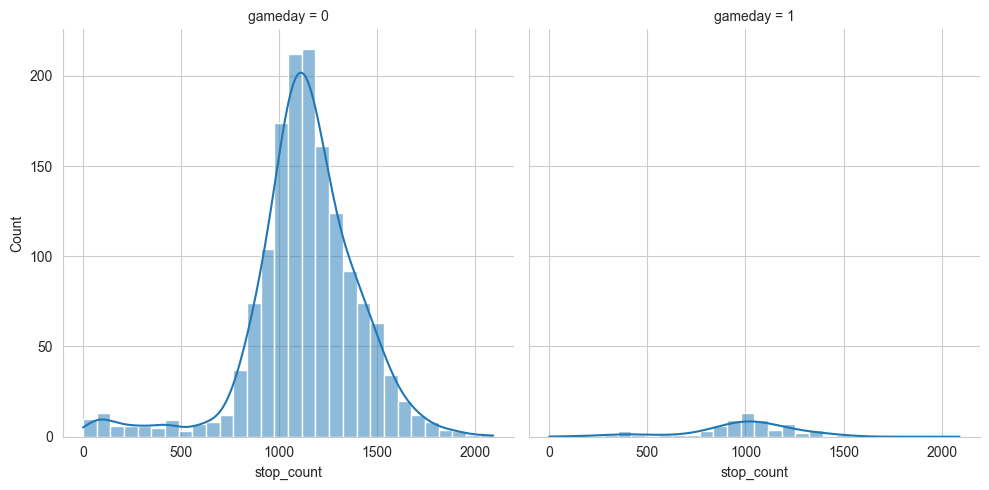

In [19]:
sns.displot(
    data=daily_stops,
    x='stop_count',
    col='gameday',
    bins=30,
    kde=True
)


## Variable distributions

In [26]:
df = pd.read_csv("../data/eagles_square_modeling_df.csv", index_col=0)
df.drop(columns=['Opp', 'TeamScore', 'OppScore', 'DefTO', 'OffTO', 'Wins', 'Losses','Giants', 'Cowboys', 'TODiff', 'StartTime', "xEndTime"], inplace=True)

df

/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_22230/4156239549.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("eagles_square_modeling_df.csv", index_col=0)


,date,hour,region,stop_count,Game,Day,Home,PointDiff,Win,OT,...,Streak,Rivalry,RegularSeason,Division,ConfChamp,SuperBowl,gameday,start_hour,end_hour,game_period
2402352,2014-09-07,0,4434_-6395,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402353,2014-09-07,0,4434_-6394,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402354,2014-09-07,0,4438_-6399,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402355,2014-09-07,0,4435_-6398,4,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
2402356,2014-09-07,0,4436_-6399,0,1,Sunday,0.0,17.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14433403,2018-02-04,23,4427_-6392,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
14433404,2018-02-04,23,4450_-6397,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
14433405,2018-02-04,23,4449_-6396,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
14433406,2018-02-04,23,4446_-6401,0,SuperBowl,Sunday,0.0,8.0,1.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after


In [28]:
df.columns

Index(['date', 'hour', 'region', 'stop_count', 'Game', 'Day', 'Home',
       'PointDiff', 'Win', 'OT', 'Season', 'Streak', 'Rivalry',
       'RegularSeason', 'Division', 'ConfChamp', 'SuperBowl', 'gameday',
       'start_hour', 'end_hour', 'game_period'],
      dtype='object')

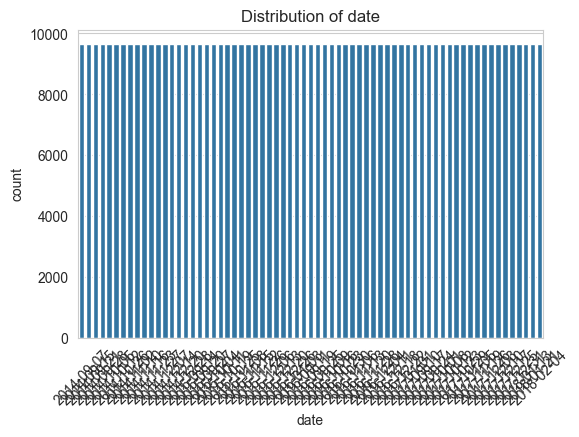

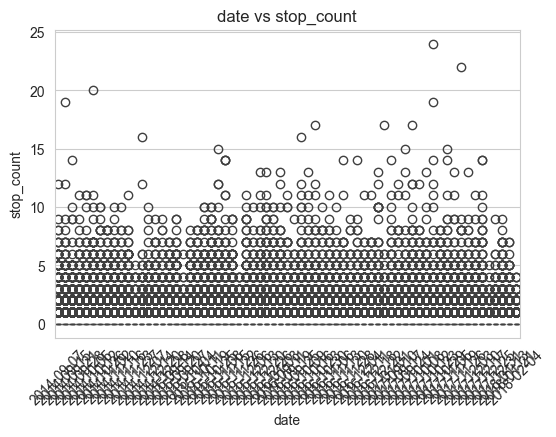

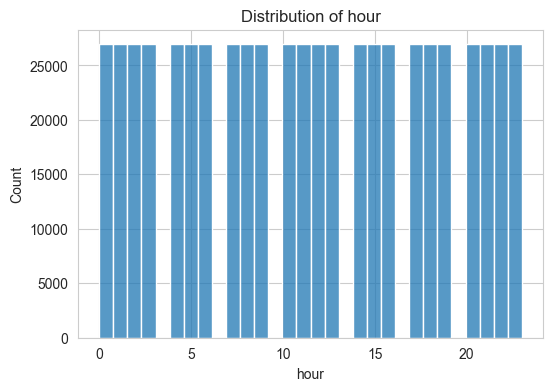

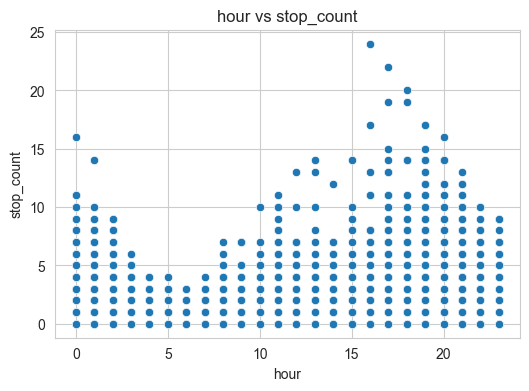

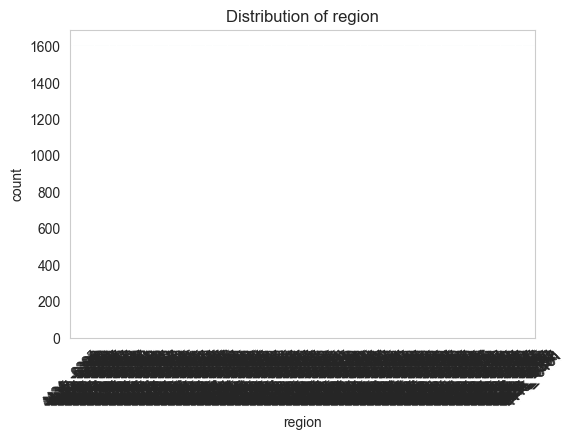

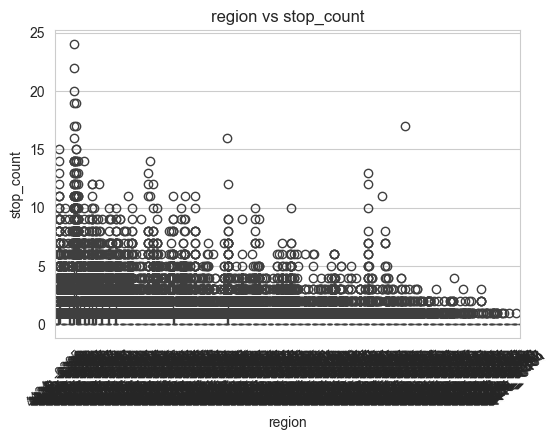

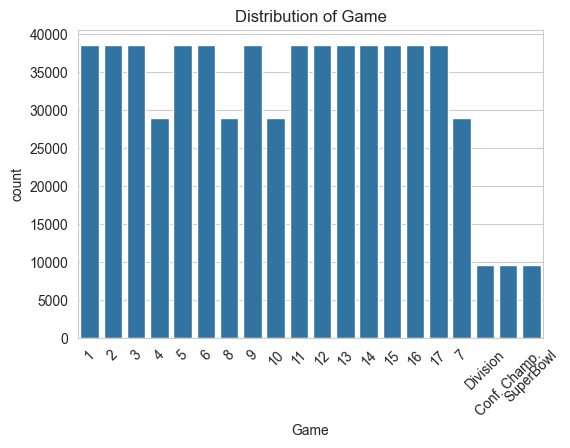

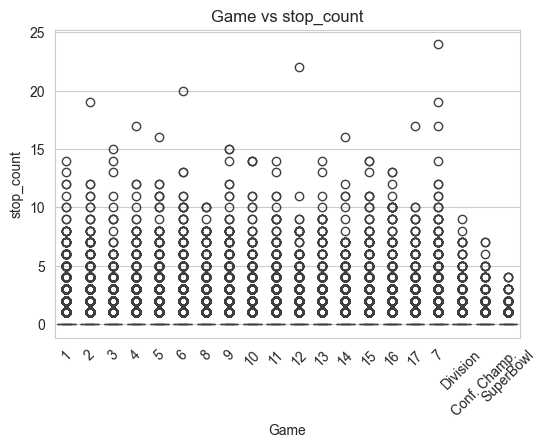

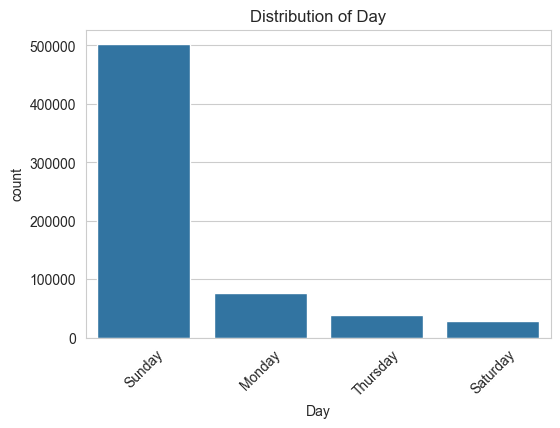

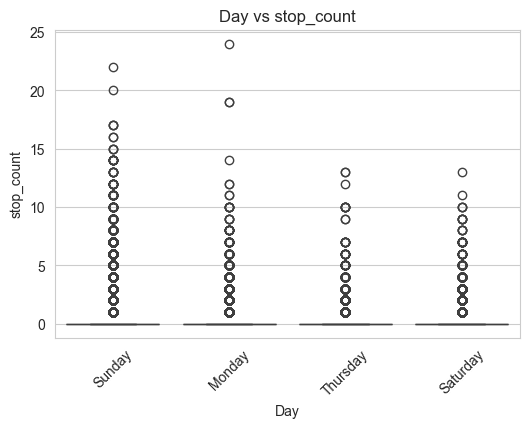

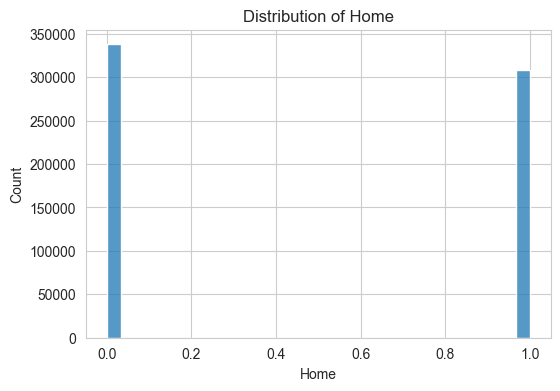

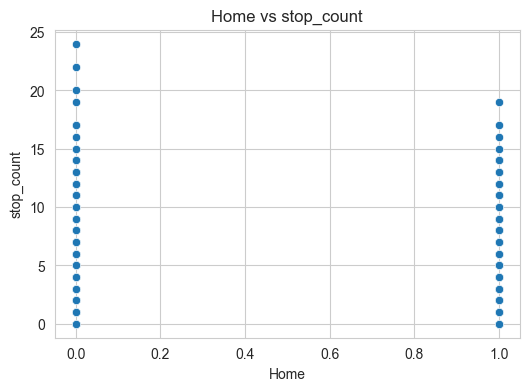

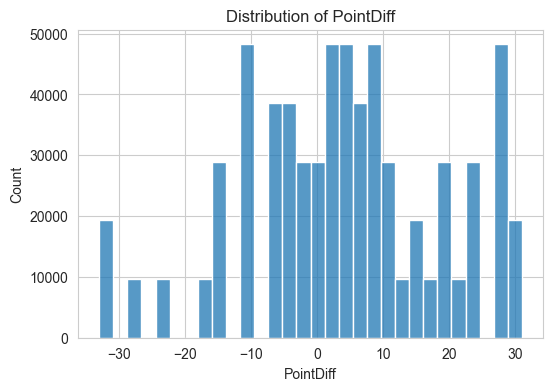

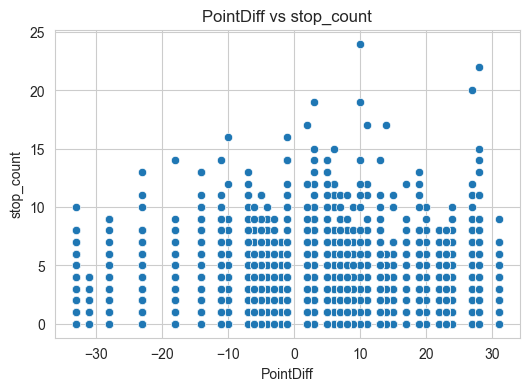

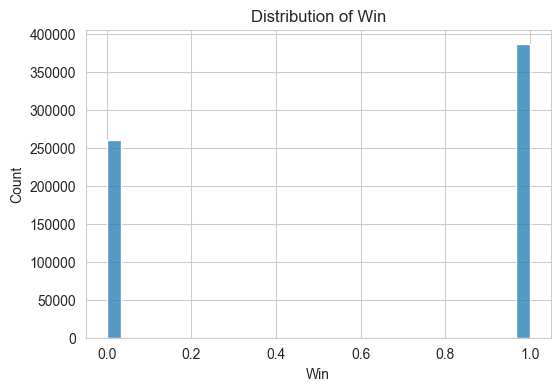

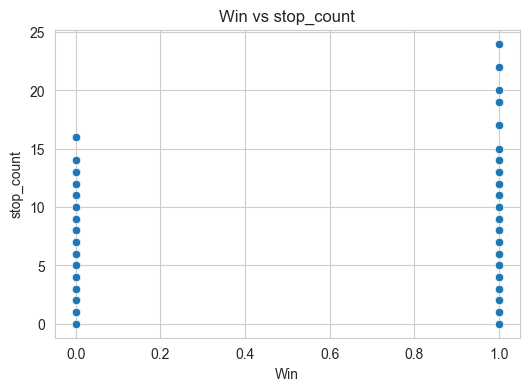

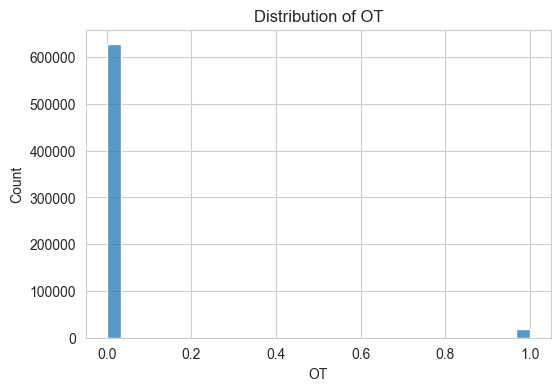

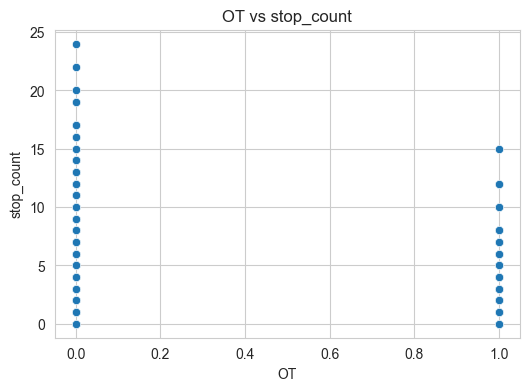

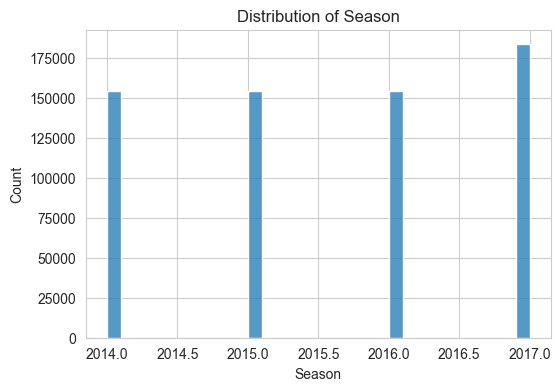

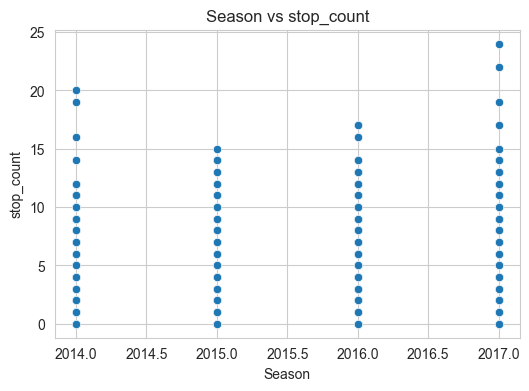

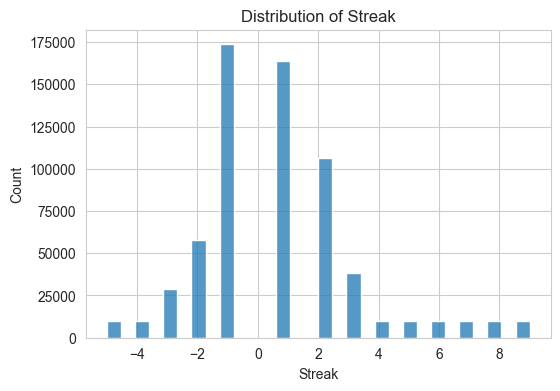

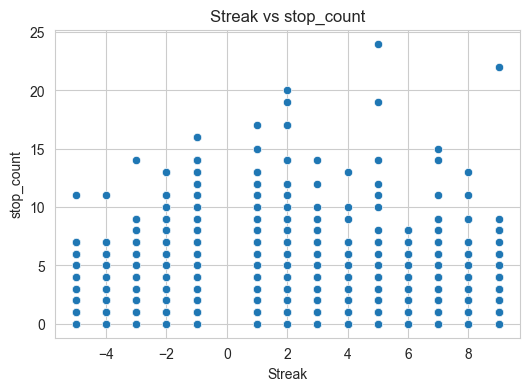

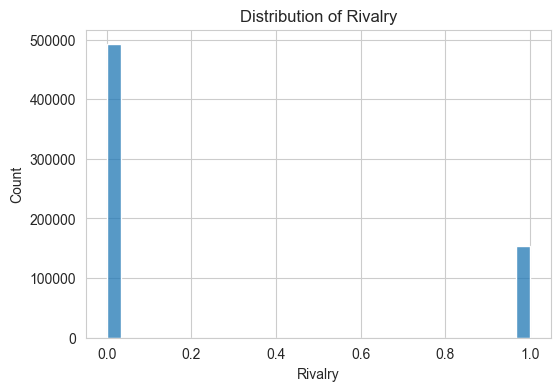

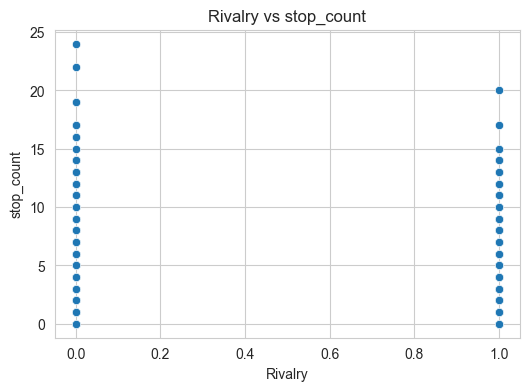

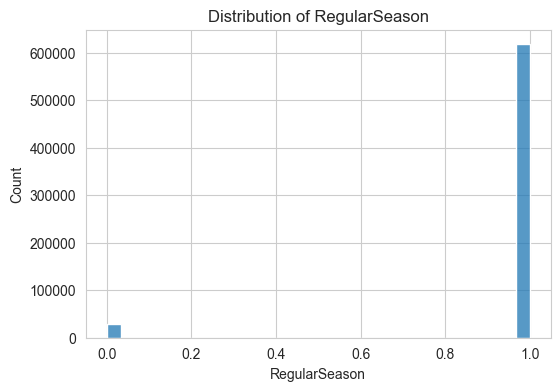

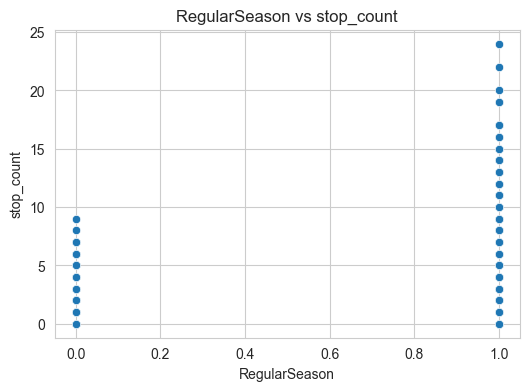

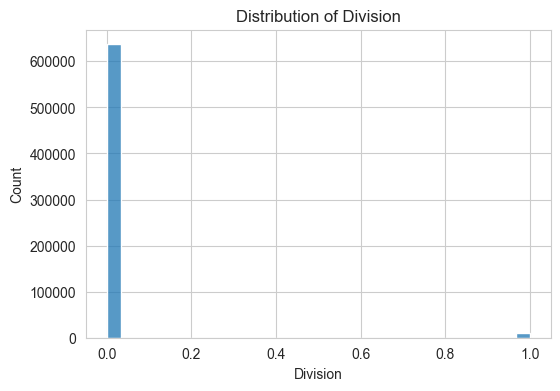

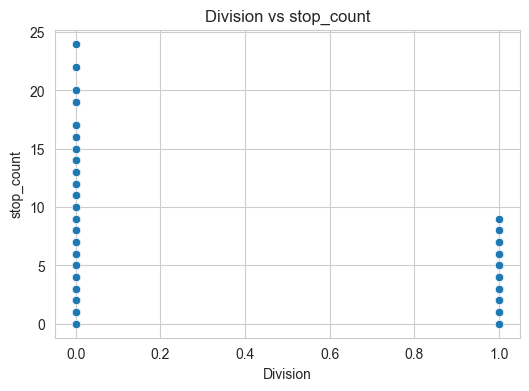

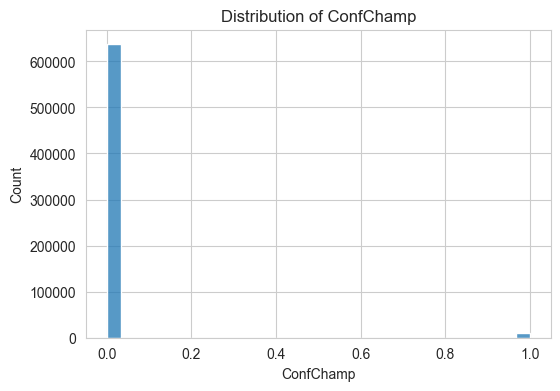

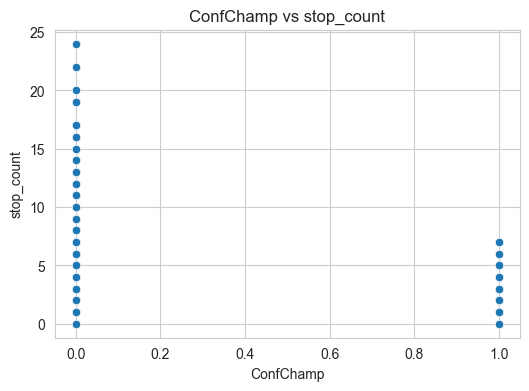

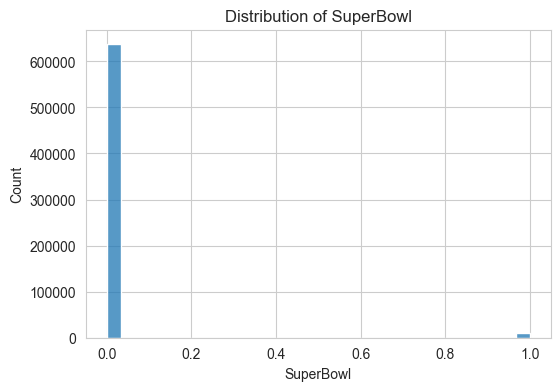

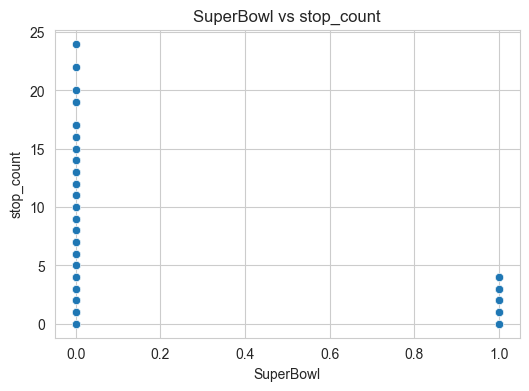

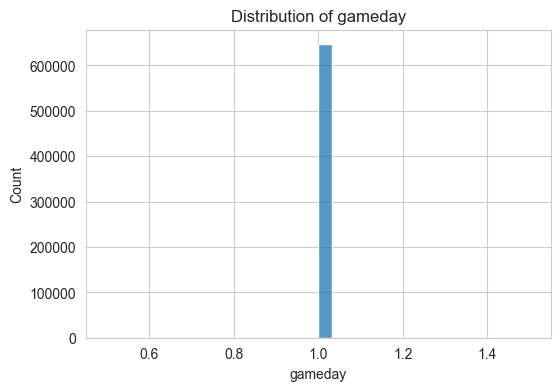

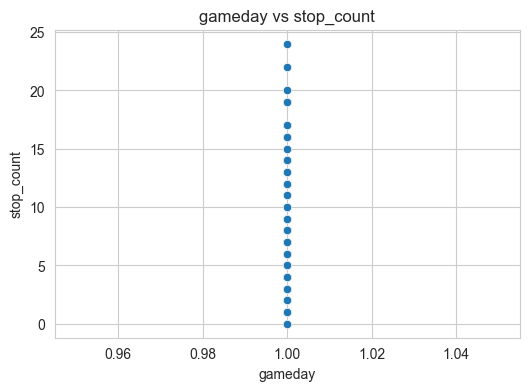

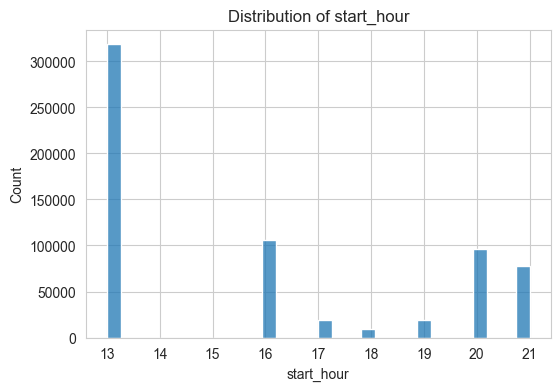

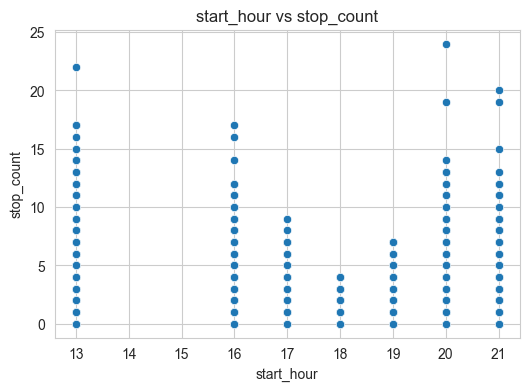

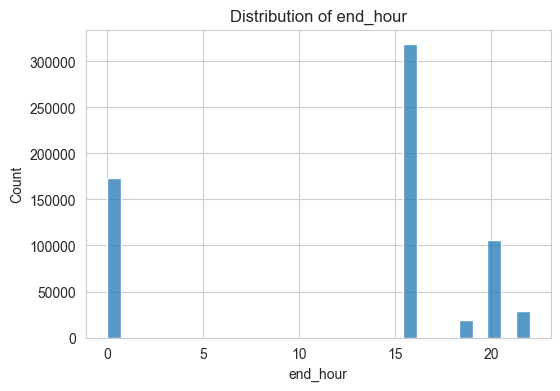

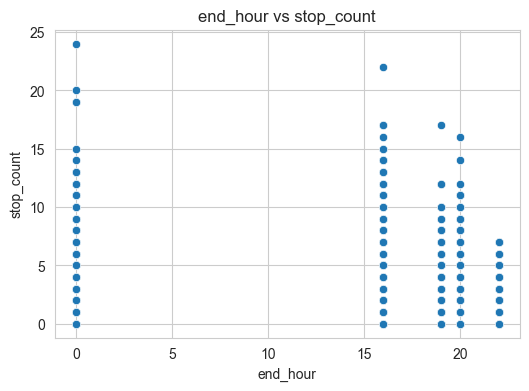

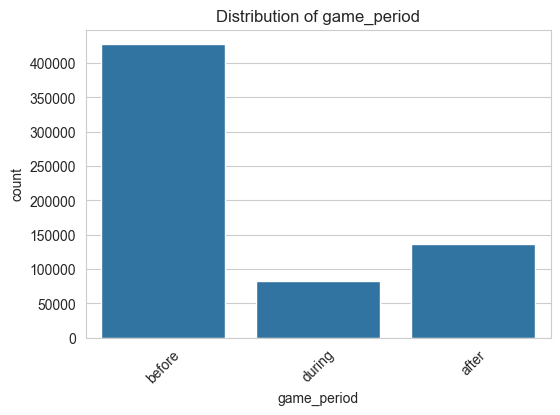

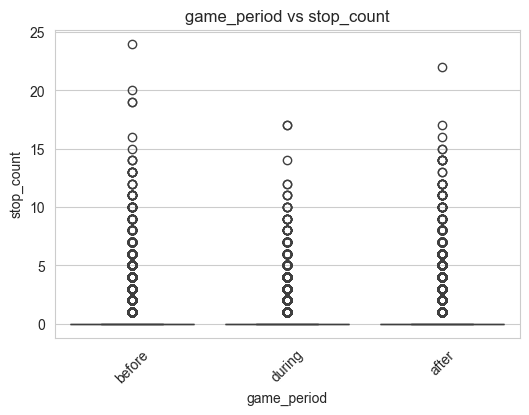

In [29]:
target = 'stop_count'

features = [col for col in df.columns if col != target]

for col in features:

    # -------- Distribution Plot --------
    plt.figure(figsize=(6,4))

    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(df[col], bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)

    else:
        sns.countplot(x=df[col])
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)

    plt.show()


    # -------- Feature vs Target --------
    plt.figure(figsize=(6,4))

    if pd.api.types.is_numeric_dtype(df[col]):
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f'{col} vs {target}')

    else:
        sns.boxplot(x=df[col], y=df[target])
        plt.title(f'{col} vs {target}')
        plt.xticks(rotation=45)

    plt.show()


## Target variable distribution

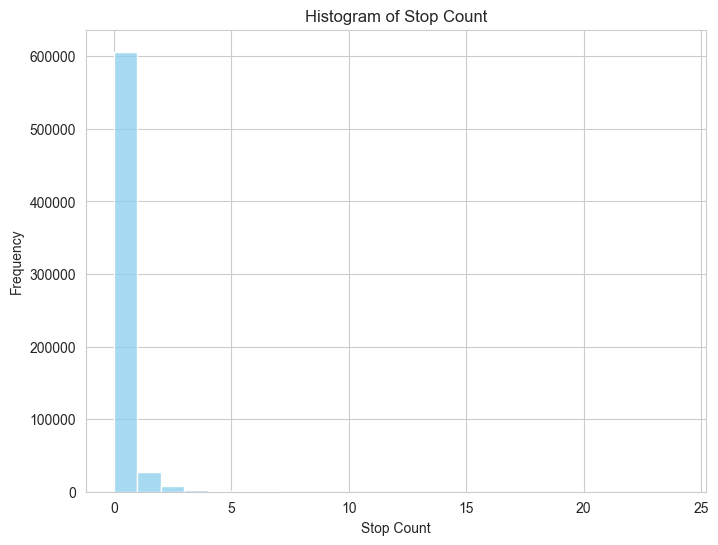

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Using seaborn
sns.histplot(df['stop_count'], bins=24, kde=False, color='skyblue')
plt.title('Histogram of Stop Count')
plt.xlabel('Stop Count')
plt.ylabel('Frequency')
plt.show()


In [39]:
# Total number of rows
total_rows = len(df)

# Number of rows where stop_count > 5
num_greater_5 = (df['stop_count'] > 5).sum()

# Proportion
proportion = num_greater_5 / total_rows
proportion
print(f"Proportion of observations with stop_count > 5: {proportion:.5f}")


Proportion of observations with stop_count > 5: 0.00120


In [35]:
# Sort stop_count from high to low
sorted_stop_counts = df['stop_count'].sort_values(ascending=False)
(sorted_stop_counts)


13426816    24
13755250    22
2747284     20
2486790     19
13427218    19
            ..
6523932      0
6523933      0
6523934      0
6523935      0
14433407     0
Name: stop_count, Length: 646416, dtype: int64